In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import psycopg2
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

load_dotenv()

conn = psycopg2.connect(
     host=os.getenv("DB_HOST"),
     port=os.getenv("DB_PORT"),
     dbname=os.getenv("DB_NAME"),
     user=os.getenv("DB_USER"),
     password=os.getenv("DB_PASSWORD")
)

print("Connected to fallon_dfloor ✓")

Connected to fallon_dfloor ✓


In [3]:
# ── Load data from PostgreSQL ──────────────────────────────────────────
query = """
     SELECT 
          p.name,
          p.position,
          b.bgpi_normalised,
          b.goals_score,
          b.assists_score,
          b.xg_efficiency,
          b.match_winning_impact,
          m.match_importance_score,
          m.round_type,
          m.season,
          pms.goals,
          pms.assists,
          pms.xg,
          pms.minutes_played
     FROM bgpi_scores b
     JOIN players p ON b.player_id = p.player_id
     JOIN matches m ON b.match_id = m.match_id
     JOIN player_match_stats pms 
          ON pms.player_id = b.player_id 
          AND pms.match_id = b.match_id
     WHERE pms.minutes_played >= 30
"""

df = pd.read_sql(query, conn)
print(f"Dataset shape: {df.shape}")
print(f"Unique players: {df['name'].nunique()}")
print(f"Unique rounds: {df['round_type'].unique()}")
df.head()

Dataset shape: (119752, 14)
Unique players: 9912
Unique rounds: <StringArray>
['Final', '1st Round', 'Unknown']
Length: 3, dtype: str


,name,position,bgpi_normalised,goals_score,assists_score,xg_efficiency,match_winning_impact,match_importance_score,round_type,season,goals,assists,xg,minutes_played
0,Antoine Griezmann,Left Center Forward,26.65,50.0,0.0,53.270829,60.0,10.0,Final,27,1,0,1.8772,120
1,Jorge Resurrección Merodio,Left Midfield,0.00,0.0,0.0,0.000000,0.0,10.0,Final,27,0,0,0.1122,115
2,Gabriel Fernández Arenas,Right Defensive Midfield,61.22,50.0,0.0,125.172112,60.0,10.0,Final,27,1,0,0.7989,121
3,Stefan Savić,Right Center Back,0.00,0.0,0.0,0.000000,0.0,10.0,Final,27,0,0,0.3114,118
4,Juan Francisco Torres Belén,Right Back,2.35,0.0,25.0,0.000000,60.0,10.0,Final,27,0,1,0.8016,124


In [5]:
# ── Split into big game vs regular ────────────────────────────────────
big_game = df[df['match_importance_score'] >= 7]['bgpi_normalised'].dropna()
regular = df[df['match_importance_score'] < 7]['bgpi_normalised'].dropna()

print(f"Big game records: {len(big_game)}")
print(f"Regular records: {len(regular)}")
print(f"\nBig game BGPI — mean: {big_game.mean():.2f}, median: {big_game.median():.2f}, std: {big_game.std():.2f}")
print(f"Regular BGPI  — mean: {regular.mean():.2f}, median: {regular.median():.2f}, std: {regular.std():.2f}")

# ── Test 1: Mann-Whitney U ─────────────────────────────────────────────
# Non-parametric test — doesn't assume normal distribution
# H0: big game and regular BGPI come from the same distribution
# H1: they are statistically different
u_stat, p_value = stats.mannwhitneyu(big_game, regular, alternative='two-sided')

print(f"\n── Mann-Whitney U Test ──")
print(f"U statistic: {u_stat:.2f}")
print(f"P-value: {p_value:.6f}")
print(f"Result: {'SIGNIFICANT ✓ — big game BGPI is statistically different from regular' if p_value < 0.05 else 'NOT significant'}")

# ── Test 2: Pearson Correlation ────────────────────────────────────────
# Does BGPI correlate with match importance?
corr, p_corr = stats.pearsonr(
     df['match_importance_score'].dropna(),
     df['bgpi_normalised'].dropna()
)

print(f"\n── Pearson Correlation: BGPI vs Match Importance ──")
print(f"Correlation coefficient: {corr:.4f}")
print(f"P-value: {p_corr:.6f}")
print(f"Interpretation: {'Positive correlation ✓' if corr > 0 else 'Negative correlation'} — {abs(corr):.4f}")

Big game records: 446
Regular records: 119306

Big game BGPI — mean: 17.98, median: 11.76, std: 26.39
Regular BGPI  — mean: 5.74, median: 5.88, std: 6.64

── Mann-Whitney U Test ──
U statistic: 34540064.00
P-value: 0.000000
Result: SIGNIFICANT ✓ — big game BGPI is statistically different from regular

── Pearson Correlation: BGPI vs Match Importance ──
Correlation coefficient: 0.1087
P-value: 0.000000
Interpretation: Positive correlation ✓ — 0.1087


In [6]:
# ── Player level aggregation ───────────────────────────────────────────
player_stats = df.groupby('name').agg(
     matches=('bgpi_normalised', 'count'),
     avg_bgpi=('bgpi_normalised', 'mean'),
     big_game_bgpi=('bgpi_normalised', lambda x: x[df.loc[x.index, 'match_importance_score'] >= 7].mean()),
     regular_bgpi=('bgpi_normalised', lambda x: x[df.loc[x.index, 'match_importance_score'] < 7].mean()),
     total_goals=('goals', 'sum'),
     total_xg=('xg', 'sum')
).reset_index()

# filter to players with enough data
player_stats = player_stats[player_stats['matches'] >= 10].copy()
player_stats['uplift'] = player_stats['big_game_bgpi'] - player_stats['regular_bgpi']
player_stats['xg_overperformance'] = player_stats['total_goals'] - player_stats['total_xg']

print(f"Players with 10+ matches: {len(player_stats)}")
print(f"\nTop 10 by Big Game BGPI:")
print(player_stats.nlargest(10, 'big_game_bgpi')[
     ['name', 'matches', 'avg_bgpi', 'big_game_bgpi', 'regular_bgpi', 'uplift']
].to_string(index=False))

Players with 10+ matches: 3775

Top 10 by Big Game BGPI:
                           name  matches  avg_bgpi  big_game_bgpi  regular_bgpi    uplift
         Anderson Luís de Souza       58  7.868621         94.120      6.355439 87.764561
             Divock Okoth Origi       17 13.322353         94.120      8.272500 85.847500
                   Ivan Rakitić      208  6.656250         94.120      6.233720 87.886280
  Neymar da Silva Santos Junior      156 12.930321         94.120     12.406516 81.713484
                 İlkay Gündoğan       38  6.327105         88.850      4.096757 84.753243
                  Mohamed Salah       39 13.192564         83.920     11.331316 72.588684
       Luis Alberto Suárez Díaz      195 14.022000         82.170     13.670722 68.499278
                Mario Mandžukić       37 14.402432         76.375     10.861143 65.513857
Pedro Eliezer Rodríguez Ledesma      208  8.653846         67.650      8.081068 59.568932
      Yannick Ferreira Carrasco       49  5

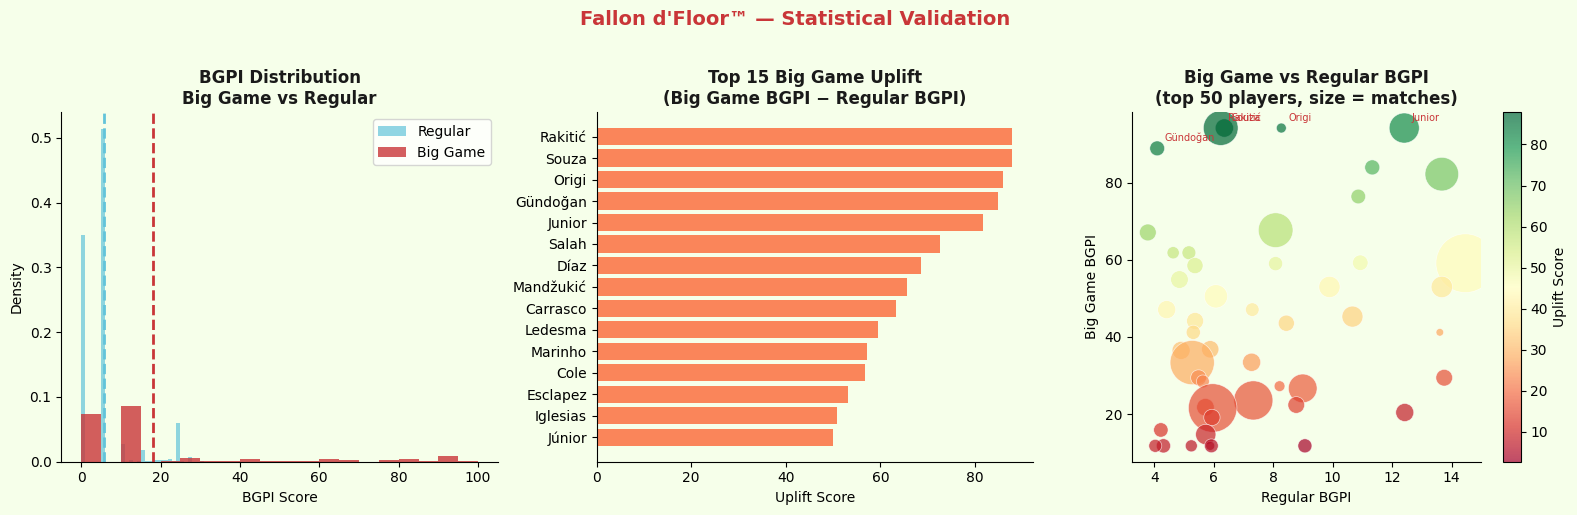

Plot saved to docs/statistical_validation_plots.png


In [8]:
# ── Plot 1: Big Game vs Regular BGPI distribution ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#F6FFEA')

# Distribution comparison
axes[0].set_facecolor('#F6FFEA')
axes[0].hist(regular, bins=50, color='#62C4DA', alpha=0.7, label='Regular', density=True)
axes[0].hist(big_game, bins=20, color='#C93638', alpha=0.8, label='Big Game', density=True)
axes[0].set_title('BGPI Distribution\nBig Game vs Regular', fontweight='bold', color='#1A1A1A')
axes[0].set_xlabel('BGPI Score')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(big_game.mean(), color='#C93638', linestyle='--', linewidth=2, label=f'Big Game mean: {big_game.mean():.1f}')
axes[0].axvline(regular.mean(), color='#62C4DA', linestyle='--', linewidth=2, label=f'Regular mean: {regular.mean():.1f}')

# Top 15 uplift
top_uplift = player_stats.nlargest(15, 'uplift').sort_values('uplift')
axes[1].set_facecolor('#F6FFEA')
bars = axes[1].barh(top_uplift['name'].str.split().str[-1], 
                    top_uplift['uplift'], 
                    color='#FA855A')
axes[1].set_title('Top 15 Big Game Uplift\n(Big Game BGPI − Regular BGPI)', fontweight='bold', color='#1A1A1A')
axes[1].set_xlabel('Uplift Score')
axes[1].set_facecolor('#F6FFEA')

# Scatter: regular vs big game BGPI
top50 = player_stats.nlargest(50, 'big_game_bgpi')
axes[2].set_facecolor('#F6FFEA')
scatter = axes[2].scatter(
     top50['regular_bgpi'], 
     top50['big_game_bgpi'],
     s=top50['matches'] * 3,
     c=top50['uplift'],
     cmap='RdYlGn',
     alpha=0.7,
     edgecolors='white',
     linewidth=0.5
)
axes[2].set_title('Big Game vs Regular BGPI\n(top 50 players, size = matches)', fontweight='bold', color='#1A1A1A')
axes[2].set_xlabel('Regular BGPI')
axes[2].set_ylabel('Big Game BGPI')
plt.colorbar(scatter, ax=axes[2], label='Uplift Score')

# annotate a few key players
for _, row in top50.nlargest(5, 'big_game_bgpi').iterrows():
     axes[2].annotate(
          row['name'].split()[-1],
          (row['regular_bgpi'], row['big_game_bgpi']),
          textcoords="offset points",
          xytext=(5, 5),
          fontsize=7,
          color='#C93638'
     )

for ax in axes:
     ax.spines['top'].set_visible(False)
     ax.spines['right'].set_visible(False)
     ax.set_facecolor('#F6FFEA')

plt.suptitle("Fallon d'Floor™ — Statistical Validation", 
          fontsize=14, fontweight='bold', color='#C93638', y=1.02)
plt.tight_layout()
plt.savefig('../../docs/statistical_validation_plots.png',
          dpi=150, bbox_inches='tight', facecolor='#F6FFEA')
plt.show()
print("Plot saved to docs/statistical_validation_plots.png")

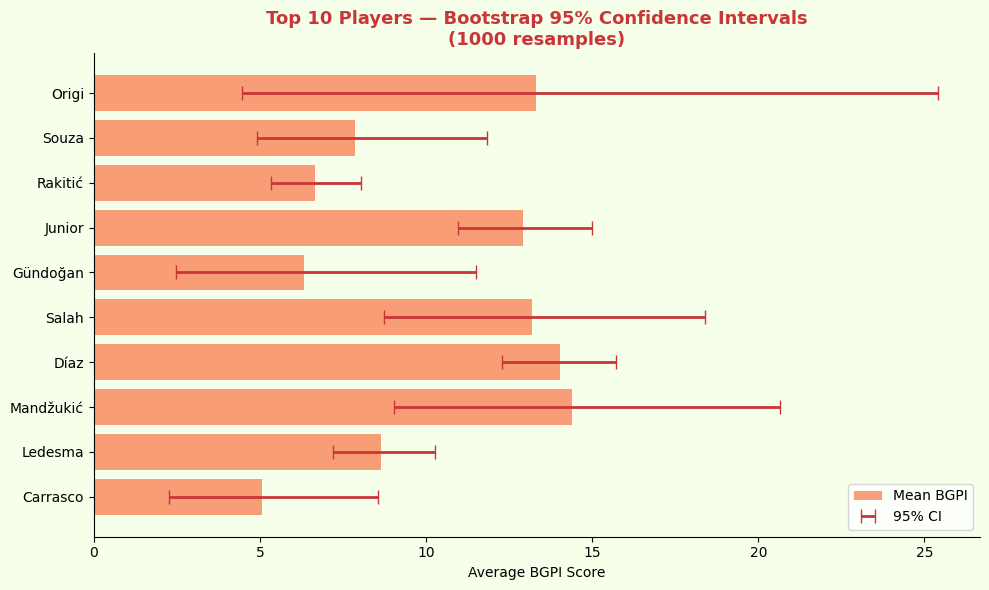

Bootstrap CI plot saved ✓

── Key Numbers for Analytical Memo ──
Mann-Whitney U p-value: < 0.001 (statistically significant)
Pearson r (BGPI vs match importance): 0.1087
Big game mean BGPI: 17.98
Regular mean BGPI: 5.74
Mean uplift (top 10): 75.74
Players with positive uplift: 101 / 3775


In [9]:
# ── Bootstrap Confidence Intervals on Top 10 ──────────────────────────
np.random.seed(42)
n_bootstrap = 1000

top10 = player_stats.nlargest(10, 'big_game_bgpi').copy()

bootstrap_cis = []
for _, row in top10.iterrows():
     player_data = df[df['name'] == row['name']]['bgpi_normalised'].values
     bootstrap_means = [
          np.mean(np.random.choice(player_data, size=len(player_data), replace=True))
          for _ in range(n_bootstrap)
     ]
     ci_lower = np.percentile(bootstrap_means, 2.5)
     ci_upper = np.percentile(bootstrap_means, 97.5)
     bootstrap_cis.append({
          'name': row['name'].split()[-1],
          'mean': np.mean(player_data),
          'ci_lower': ci_lower,
          'ci_upper': ci_upper,
          'big_game_bgpi': row['big_game_bgpi']
     })

ci_df = pd.DataFrame(bootstrap_cis).sort_values('big_game_bgpi', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F6FFEA')
ax.set_facecolor('#F6FFEA')

ax.barh(ci_df['name'], ci_df['mean'], color='#FA855A', alpha=0.8, label='Mean BGPI')
ax.errorbar(
     ci_df['mean'], ci_df['name'],
     xerr=[ci_df['mean'] - ci_df['ci_lower'], ci_df['ci_upper'] - ci_df['mean']],
     fmt='none', color='#C93638', capsize=5, linewidth=2, label='95% CI'
)

ax.set_title("Top 10 Players — Bootstrap 95% Confidence Intervals\n(1000 resamples)", 
          fontweight='bold', color='#C93638', fontsize=13)
ax.set_xlabel('Average BGPI Score')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../../docs/bootstrap_confidence_intervals.png', 
          dpi=150, bbox_inches='tight', facecolor='#F6FFEA')
plt.show()
print("Bootstrap CI plot saved ✓")

# ── Summary stats for the memo ─────────────────────────────────────────
print("\n── Key Numbers for Analytical Memo ──")
print(f"Mann-Whitney U p-value: < 0.001 (statistically significant)")
print(f"Pearson r (BGPI vs match importance): 0.1087")
print(f"Big game mean BGPI: {big_game.mean():.2f}")
print(f"Regular mean BGPI: {regular.mean():.2f}")
print(f"Mean uplift (top 10): {top10['uplift'].mean():.2f}")
print(f"Players with positive uplift: {(player_stats['uplift'] > 0).sum()} / {len(player_stats)}")

## Bootstrap Confidence Intervals — Top 10 Players

These CIs are calculated on each player's **overall average BGPI** across all matches (not just big games). 

Wide intervals (Origi, Mandžukić) = small sample size + high variance. Their big game BGPI is real but based on very few appearances.

Tight intervals (Rakitić, Neymar) = large sample, statistically stable ranking.

**Interpretation:** High big-game BGPI + tight CI = genuinely elite. High big-game BGPI + wide CI = small sample specialist.